In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.insert(0, '../scripts')
from utils import get_all_interactions

In [5]:
fp = "../data/survey/DANTE_Pilot_October 13, 2025_21.48.csv"
df = pd.read_csv(fp)
df = df.drop(index=[0,1])

get_all_interactions(df)

# remove internal test cases
df = df[df['participantId'] != ""]

# remove unfinished cases
df = df[df['Finished']=="True"]

# remove cases with no summary
df = df.dropna(subset=['summary', 'llm_response_1'])

# remove certain participants (HTTP and DOM errors with erroneous interactions)
error = ["6B5DC61D3F1A4FD59884E09A7390D115", "9C157F56FEEC4F22BAFEEC11763B9759", "F6586134F687435A9064E1C721EBC99F", "AF09ECC56B13406EAA4D174850B78291", "F28F21C7F66946B785FCCA3E4AEB26B2"]
duplicate_ip = ['3E8D695768544BFAAB256B25B286BE36', '2C25201441924CD69CFB850F9E0C25B7', 'ADE33812DFEE4679855302BB37ABFF84']
dnf = ['498B2C7CFDC6421A8DE46C96D56EFBB2', '57A3377A53CD49C3A03640AC86E08698', '6AEA21E0CC19480D95EF78972E41A441']
df = df[df['participantId'].apply(lambda x: x not in error+duplicate_ip+dnf)]

# Convo satisfaction to numeric
str_to_num = {"Strongly disagree": 1, "Somewhat disagree": 2, "Neither agree nor disagree": 3, "Somewhat agree": 4, "Strongly agree": 5}

for col in ['satis1', 'satis2']:
    df[col] = df[col].map(str_to_num)

# Treatment labels to more readable format
df['treatment'] = df['treatment'].apply(lambda x: f"{x.split('_')[0].capitalize()} {x.split('_')[1].capitalize()}")

# Average satisfaction
df['satis_avg'] = (df['satis1'] + df['satis2']) / 2

# Agree vs Disagree
df['agree_disagree'] = "Agree"
df.loc[df['treatment'].apply(lambda x: "Disagree" in x), 'agree_disagree'] = "Disagree"

# Ingroup vs Outgroup
df['ingroup_outgroup'] = "Ingroup"
df.loc[df['treatment'].apply(lambda x: "Outgroup" in x), 'ingroup_outgroup'] = "Outgroup"

In [ ]:
df_melt = df.melt(id_vars=['pid', 'participantId', 'agree_disagree', 'ingroup_outgroup'], value_vars=['pre_feel_rep_1', 'pre_feel_dem_1'])

# Filter to keep only Democrats and Republicans
df_melt = df_melt[(df_melt['pid'] == 'Democrat') | (df_melt['pid'] == 'Republican')]

# Convert feeling thermometer values to int
df_melt['value'] = df_melt['value'].astype(int)

# Map variable names to more readable format
df_melt['variable'] = df_melt['variable'].map({"pre_feel_rep_1":"Republican", "pre_feel_dem_1":"Democrat"})

In [72]:
df_melt.loc[(df_melt['pid']=='Democrat') & (df_melt['variable']=='Democrat'), 'value'].mean() - df_melt.loc[(df_melt['pid']=='Democrat') & (df_melt['variable']=='Republican'), 'value'].mean()
df_melt.loc[(df_melt['pid']=='Republican') & (df_melt['variable']=='Republican'), 'value'].mean() - df_melt.loc[(df_melt['pid']=='Republican') & (df_melt['variable']=='Democrat'), 'value'].mean()

np.float64(44.609357997823714)

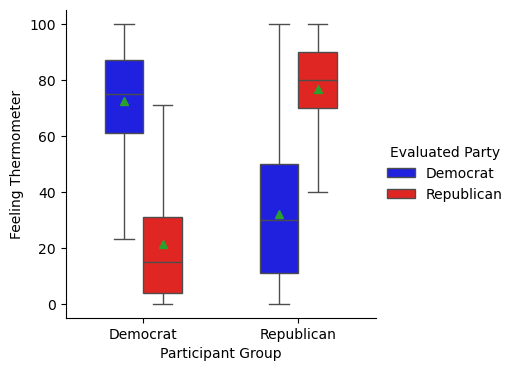

In [52]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=df_melt, x='pid', y='value', hue='variable', hue_order=['Democrat', 'Republican'], palette=['#0000ff', '#ff0803'],
            showfliers=False,
            width=0.5,
            showmeans=True,
            ax = ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Feeling Thermometer')
ax.set_xlabel('Participant Group')

ax.legend(frameon=False, loc='upper right', title='Evaluated Party', bbox_to_anchor=(1.45, .6))

fig.savefig('../figures/affective_polarization_pre_treatment.pdf', bbox_inches='tight', transparent=True)
fig.savefig('../figures/affective_polarization_pre_treatment.png', bbox_inches='tight', dpi=600, transparent=True)